# Credit Card Fraud Detection Meta-Learner & Evaluation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, IsolationForest,
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, precision_recall_curve,
    confusion_matrix,
)
import xgboost as xgb
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

SEED = 42
N_FOLDS = 5
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 1. Load Base Model Outputs

In [2]:
META_DIR = "../data/outputs"

# Labels
y_train = pd.read_csv(f"{META_DIR}/y_train.csv")["Class"].values.astype(np.float32)
y_val = pd.read_csv(f"{META_DIR}/y_eval.csv")["Class"].values.astype(np.float32)
y_test = pd.read_csv(f"{META_DIR}/y_test.csv")["Class"].values.astype(np.float32)

_train = pd.read_csv(f"{META_DIR}/meta_x_train.csv")
_val = pd.read_csv(f"{META_DIR}/meta_x_eval.csv")
_test = pd.read_csv(f"{META_DIR}/meta_x_test.csv")

# FFN
ffn_train_oof = _train["ffn"].values.astype(np.float32)
ffn_val_probs = _val["ffn"].values.astype(np.float32)
ffn_test_probs = _test["ffn"].values.astype(np.float32)

# XGBoost
xgb_train_oof = _train["xgboost"].values.astype(np.float32)
xgb_val_probs = _val["xgboost"].values.astype(np.float32)
xgb_test_probs = _test["xgboost"].values.astype(np.float32)

# Autoencoder
ae_train_probs = _train["autoencoder"].values.astype(np.float32)
ae_val_probs = _val["autoencoder"].values.astype(np.float32)
ae_test_probs = _test["autoencoder"].values.astype(np.float32)

# Isolation Forest
if_train_probs = _train["isolation_forest"].values.astype(np.float32)
if_val_probs = _val["isolation_forest"].values.astype(np.float32)
if_test_probs = _test["isolation_forest"].values.astype(np.float32)

print(f"Train: {len(y_train):,} ({int(y_train.sum())} fraud)")
print(f"Val: {len(y_val):,} ({int(y_val.sum())} fraud)")
print(f"Test: {len(y_test):,} ({int(y_test.sum())} fraud)")

Train: 198,608 (331 fraud)
Val: 42,559 (71 fraud)
Test: 42,559 (71 fraud)


## 2. Meta-Learner Comparison

The meta-learner sees **4 features** per sample: `[FFN_prob, XGB_prob, AE_anomaly, IF_anomaly]`.

In [3]:
meta_X_train = np.column_stack([ffn_train_oof, xgb_train_oof, ae_train_probs, if_train_probs])
meta_X_val = np.column_stack([ffn_val_probs, xgb_val_probs, ae_val_probs, if_val_probs])
meta_X_test = np.column_stack([ffn_test_probs, xgb_test_probs, ae_test_probs, if_test_probs])

print(f"meta_X_train: {meta_X_train.shape} ({int(y_train.sum())} fraud)")
print(f"meta_X_val: {meta_X_val.shape}")
print(f"meta_X_test: {meta_X_test.shape}")
print(f"Features: [FFN_prob, XGB_prob, AE_anomaly, IF_anomaly]\n")

SVM_SUBSAMPLE = 20_000
svm_idx, _ = train_test_split(np.arange(len(meta_X_train)), train_size=SVM_SUBSAMPLE,
                              random_state=SEED, stratify=y_train)
meta_X_svm = meta_X_train[svm_idx]
y_svm = y_train[svm_idx]
print(f"SVM subsample: {meta_X_svm.shape} ({int(y_svm.sum())} fraud)\n")

meta_learner_defs = {
    "LR": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED),
    "RF": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=SEED, n_jobs=-1),
    "GBM": GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    "SVM": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED),
    "MLP": MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=500, random_state=SEED),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=SEED),
}

meta_results = {}
for name, clf in meta_learner_defs.items():
    X_fit = meta_X_svm if name == "SVM" else meta_X_train
    y_fit = y_svm if name == "SVM" else y_train
    clf.fit(X_fit, y_fit)
    meta_results[name] = {
        "val_probs": clf.predict_proba(meta_X_val)[:, 1],
        "test_probs": clf.predict_proba(meta_X_test)[:, 1],
    }
    print(f"  Trained: Meta-{name}")

meta_X_train: (198608, 4) (331 fraud)
meta_X_val: (42559, 4)
meta_X_test: (42559, 4)
Features: [FFN_prob, XGB_prob, AE_anomaly, IF_anomaly]

SVM subsample: (20000, 4) (33 fraud)

  Trained: Meta-LR
  Trained: Meta-RF
  Trained: Meta-GBM
  Trained: Meta-SVM
  Trained: Meta-MLP
  Trained: Meta-AdaBoost


## 3. Evaluation

In [4]:
def best_threshold_f1(probs, labels):
    thresholds = np.linspace(0.01, 0.99, 200)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        f1 = f1_score(labels, (probs >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


def evaluate(name, test_probs, val_probs, y_test, y_val):
    thresh, _ = best_threshold_f1(val_probs, y_val)
    preds = (test_probs >= thresh).astype(int)
    return {
        "name": name,
        "thresh": thresh,
        "F1": f1_score(y_test, preds, zero_division=0),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "AUC-PR": average_precision_score(y_test, test_probs),
        "preds": preds,
        "test_probs": test_probs,
        "val_probs": val_probs,
    }


# Base models individually
res_ffn = evaluate("FFN", ffn_test_probs, ffn_val_probs, y_test, y_val)
res_xgb = evaluate("XGBoost", xgb_test_probs, xgb_val_probs, y_test, y_val)
res_ae = evaluate("Autoencoder", ae_test_probs, ae_val_probs, y_test, y_val)
res_if = evaluate("Isolation Forest", if_test_probs, if_val_probs, y_test, y_val)

# Meta-learners
meta_eval = {
    name: evaluate(f"Meta-{name}", d["test_probs"], d["val_probs"], y_test, y_val)
    for name, d in meta_results.items()
}

all_results = [res_ffn, res_xgb, res_ae, res_if] + list(meta_eval.values())

print(f"{'Model':<24} {'Thresh':>7} {'F1':>7} {'Prec':>7} {'Rec':>7} {'AUC-PR':>8}")
print("-" * 72)
for r in all_results:
    tag = "  ◄ base" if r["name"] in {"FFN", "XGBoost", "Autoencoder", "Isolation Forest"} else ""
    print(f"{r['name']:<24} {r['thresh']:>7.3f} {r['F1']:>7.4f} {r['Precision']:>7.4f} {r['Recall']:>7.4f} {r['AUC-PR']:>8.4f}{tag}")

Model                     Thresh      F1    Prec     Rec   AUC-PR
------------------------------------------------------------------------
FFN                        0.990  0.6829  0.6022  0.7887   0.6635  ◄ base
XGBoost                    0.241  0.8244  0.9000  0.7606   0.8106  ◄ base
Autoencoder                0.990  0.1942  0.1105  0.8028   0.3705  ◄ base
Isolation Forest           0.990  0.1988  0.1264  0.4648   0.1301  ◄ base
Meta-LR                    0.990  0.8308  0.9153  0.7606   0.7887
Meta-RF                    0.369  0.8308  0.9153  0.7606   0.7341
Meta-GBM                   0.059  0.1978  0.4500  0.1268   0.0976
Meta-SVM                   0.040  0.3017  0.1882  0.7606   0.0913
Meta-MLP                   0.266  0.8308  0.9153  0.7606   0.7880
Meta-AdaBoost              0.483  0.8346  0.9464  0.7465   0.7370


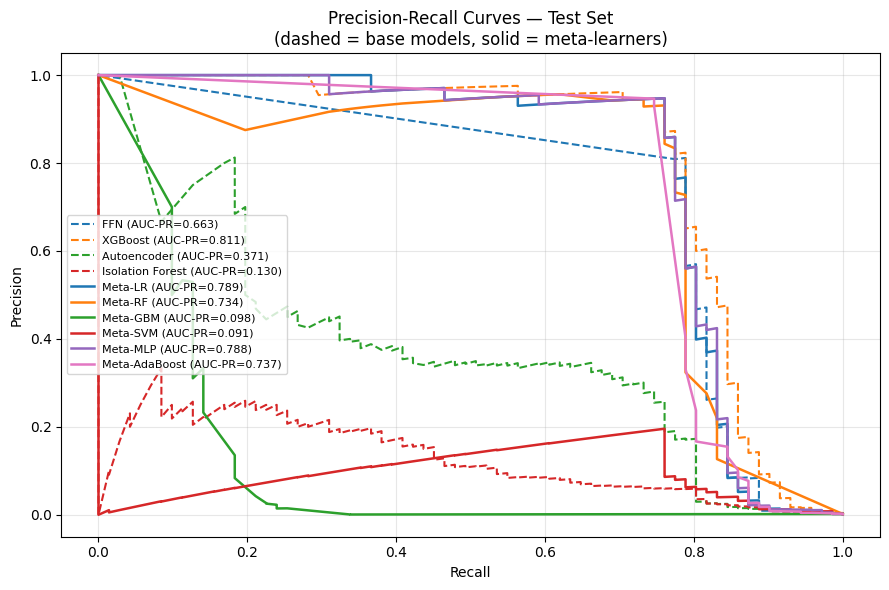

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
for res, ls, lw in [(res_ffn, "--", 1.5), (res_xgb, "--", 1.5), (res_ae, "--", 1.5), (res_if, "--", 1.5)]:
    p, r, _ = precision_recall_curve(y_test, res["test_probs"])
    ax.plot(r, p, linestyle=ls, linewidth=lw, label=f"{res['name']} (AUC-PR={res['AUC-PR']:.3f})")

colors = plt.cm.tab10(np.linspace(0, 0.6, len(meta_eval)))
for (name, res), color in zip(meta_eval.items(), colors):
    p, r, _ = precision_recall_curve(y_test, res["test_probs"])
    ax.plot(r, p, color=color, linewidth=1.8, label=f"{res['name']} (AUC-PR={res['AUC-PR']:.3f})")

ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — Test Set\n(dashed = base models, solid = meta-learners)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

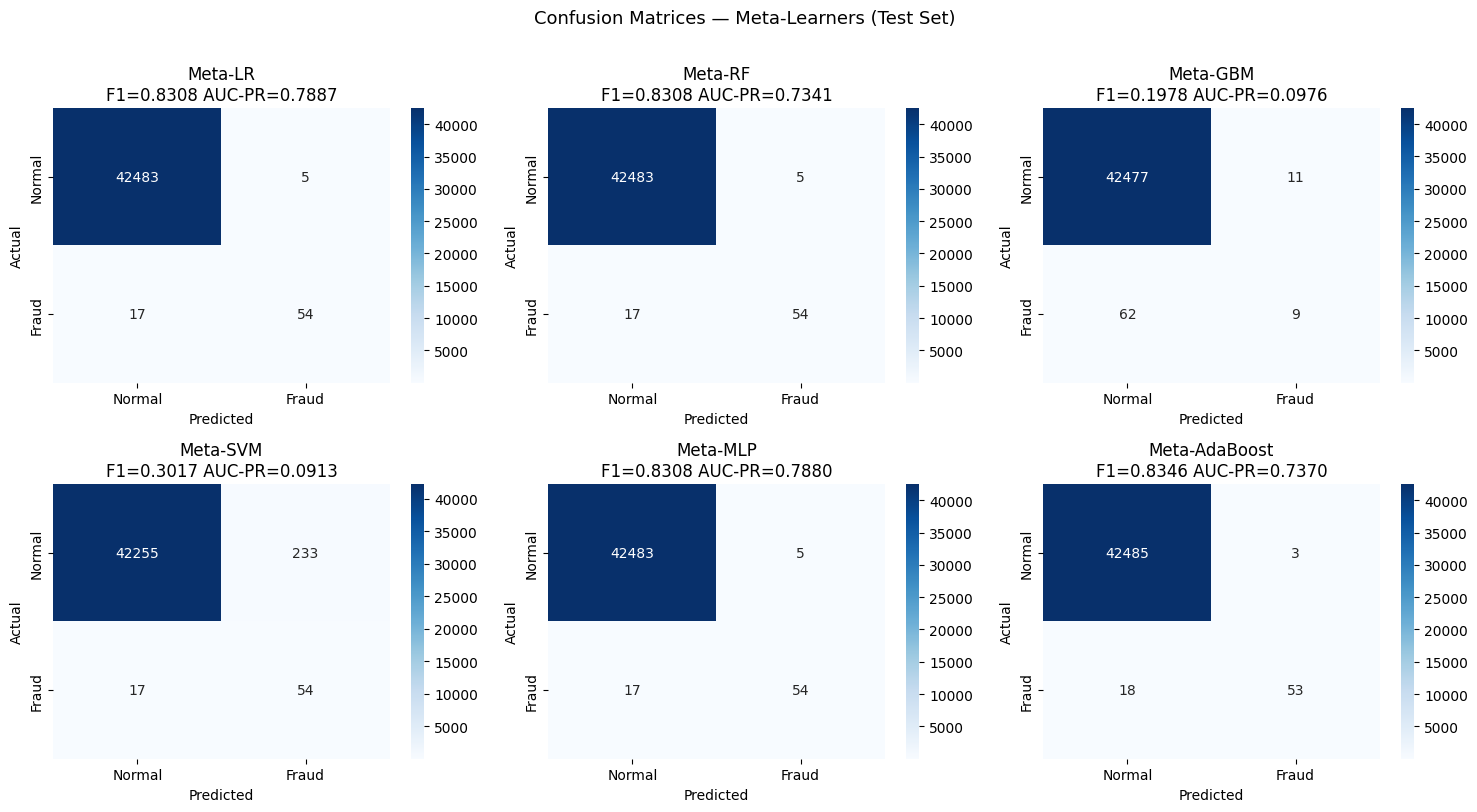

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, res) in zip(axes.flat, meta_eval.items()):
    cm = confusion_matrix(y_test, res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"])
    ax.set_title(f"{res['name']}\nF1={res['F1']:.4f} AUC-PR={res['AUC-PR']:.4f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices — Meta-Learners (Test Set)", y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

## 4. Cost-Sensitive Threshold Tuning

Minimize `10 × FN + 1 × FP`, False Positive vs False Negative

In [7]:
FN_COST, FP_COST = 10, 1

def cost_sensitive_threshold(val_probs, test_probs, y_val, y_test):
    thresholds = np.linspace(0.01, 0.99, 300)
    best_t, best_cost = 0.5, float("inf")
    for t in thresholds:
        preds = (val_probs >= t).astype(int)
        cm = confusion_matrix(y_val, preds, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        c = FN_COST * fn + FP_COST * fp
        if c < best_cost:
            best_cost, best_t = c, t
    preds_test = (test_probs >= best_t).astype(int)
    cm_test = confusion_matrix(y_test, preds_test, labels=[0, 1])
    tn, fp, fn, tp = cm_test.ravel()
    return best_t, FN_COST * fn + FP_COST * fp, f1_score(y_test, preds_test, zero_division=0)

print(f"{'Model':<24} {'Threshold':>10} {'Cost':>8} {'F1':>7}")
print("-" * 56)
for r in all_results:
    t, cost, f1 = cost_sensitive_threshold(r["val_probs"], r["test_probs"], y_val, y_test)
    print(f"{r['name']:<24} {t:>10.3f} {cost:>8.0f} {f1:>7.4f}")

Model                     Threshold     Cost      F1
--------------------------------------------------------
FFN                           0.990      187  0.6829
XGBoost                       0.017      179  0.7179
Autoencoder                   0.990      599  0.1942
Isolation Forest              0.990      608  0.1988
Meta-LR                       0.961      176  0.7746
Meta-RF                       0.056      182  0.7044
Meta-GBM                      0.059      631  0.1978
Meta-SVM                      0.039      403  0.3017
Meta-MLP                      0.043      172  0.7971
Meta-AdaBoost                 0.482      183  0.8346


## 5. Summary

=== Test Set Results ===


,F1,Precision,Recall,AUC-PR
Model,,,,
FFN,0.6829,0.6022,0.7887,0.6635
XGBoost,0.8244,0.9000,0.7606,0.8106
Autoencoder,0.1942,0.1105,0.8028,0.3705
Isolation Forest,0.1988,0.1264,0.4648,0.1301
Meta-LR,0.8308,0.9153,0.7606,0.7887
Meta-RF,0.8308,0.9153,0.7606,0.7341
Meta-GBM,0.1978,0.4500,0.1268,0.0976
Meta-SVM,0.3017,0.1882,0.7606,0.0913
Meta-MLP,0.8308,0.9153,0.7606,0.7880


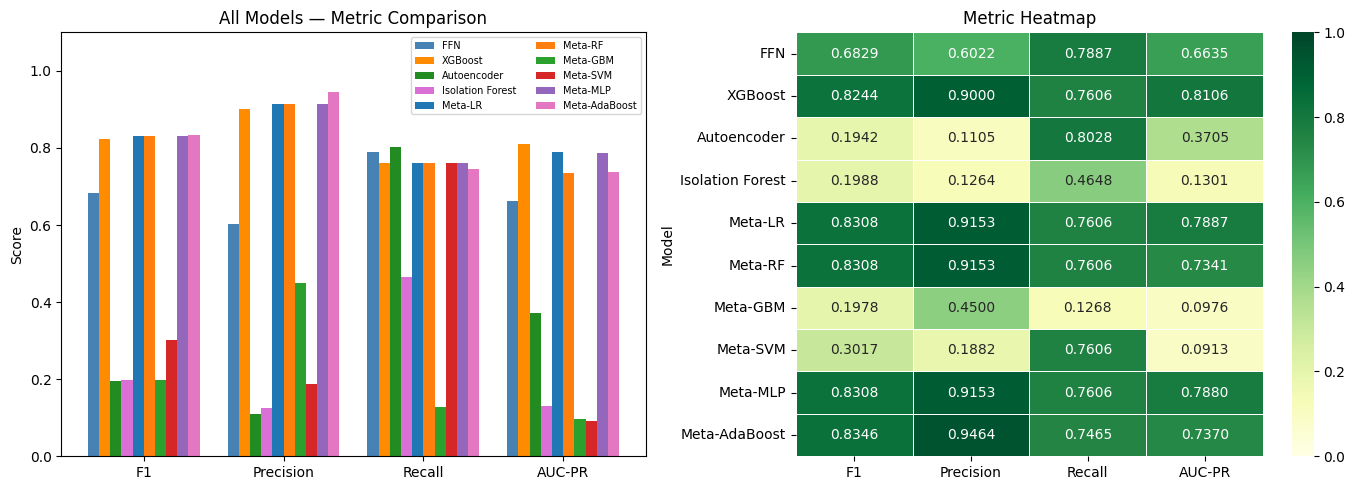


Best meta-learner: Meta-AdaBoost F1=0.8346 AUC-PR=0.7370


In [8]:
summary_df = pd.DataFrame([
    {"Model": r["name"], "F1": round(r["F1"], 4), "Precision": round(r["Precision"], 4),
     "Recall": round(r["Recall"], 4), "AUC-PR": round(r["AUC-PR"], 4)}
    for r in all_results
]).set_index("Model")

styled = summary_df.style.highlight_max(axis=0, props="font-weight: bold; color: darkgreen;").format("{:.4f}")
print("=== Test Set Results ===")
display(styled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ["F1", "Precision", "Recall", "AUC-PR"]
x = np.arange(len(metrics))
n, width = len(all_results), 0.8 / len(all_results)
colors = ["steelblue", "darkorange", "forestgreen", "orchid"] + list(plt.cm.tab10(np.linspace(0, 0.6, len(meta_eval))))
for i, (r, color) in enumerate(zip(all_results, colors)):
    vals = [r["F1"], r["Precision"], r["Recall"], r["AUC-PR"]]
    axes[0].bar(x + i*width - (n-1)*width/2, vals, width, label=r["name"], color=color)
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.1); axes[0].set_ylabel("Score")
axes[0].set_title("All Models — Metric Comparison")
axes[0].legend(fontsize=7, ncol=2)

sns.heatmap(summary_df, annot=True, fmt=".4f", cmap="YlGn", linewidths=0.5, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Metric Heatmap")
plt.tight_layout(); plt.show()

best_meta = max(meta_eval.values(), key=lambda r: r["F1"])
print(f"\nBest meta-learner: {best_meta['name']} F1={best_meta['F1']:.4f} AUC-PR={best_meta['AUC-PR']:.4f}")

In [9]:
RESULTS_DIR = "../data/outputs/results"
import os; os.makedirs(RESULTS_DIR, exist_ok=True)

def results_to_df(results, dataset="CreditCard"):
    rows = []
    for r in results:
        rows.append({
            "dataset": dataset,
            "model": r["name"],
            "threshold": round(r["thresh"], 4),
            "f1": round(r["F1"], 4),
            "precision": round(r["Precision"], 4),
            "recall": round(r["Recall"], 4),
            "auc_pr": round(r["AUC-PR"], 4),
        })
    return pd.DataFrame(rows)

cc_results_df = results_to_df(all_results, dataset="CreditCard")
cc_results_df.to_csv(f"{RESULTS_DIR}/creditcard_results.csv", index=False)
print("Saved creditcard_results.csv")
print(cc_results_df.to_string(index=False))

Saved creditcard_results.csv
   dataset            model  threshold     f1  precision  recall  auc_pr
CreditCard              FFN     0.9900 0.6829     0.6022  0.7887  0.6635
CreditCard          XGBoost     0.2415 0.8244     0.9000  0.7606  0.8106
CreditCard      Autoencoder     0.9900 0.1942     0.1105  0.8028  0.3705
CreditCard Isolation Forest     0.9900 0.1988     0.1264  0.4648  0.1301
CreditCard          Meta-LR     0.9900 0.8308     0.9153  0.7606  0.7887
CreditCard          Meta-RF     0.3695 0.8308     0.9153  0.7606  0.7341
CreditCard         Meta-GBM     0.0592 0.1978     0.4500  0.1268  0.0976
CreditCard         Meta-SVM     0.0395 0.3017     0.1882  0.7606  0.0913
CreditCard         Meta-MLP     0.2661 0.8308     0.9153  0.7606  0.7880
CreditCard    Meta-AdaBoost     0.4828 0.8346     0.9464  0.7465  0.7370


## 6. BankSim Generalizability Experiment

In [10]:
# Class definitions
class FraudDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class FFN(nn.Module):
    def __init__(self, input_dim, hidden_dims=(128, 64, 32), dropout=0.3):
        super().__init__()
        layers, prev = [], input_dim
        for i, h in enumerate(hidden_dims):
            layers += [nn.Linear(prev, h), nn.ReLU()]
            if i < len(hidden_dims) - 1:
                layers += [nn.BatchNorm1d(h), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(1)

class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims=(16, 8)):
        super().__init__()
        enc, prev = [], input_dim
        for h in hidden_dims:
            enc += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        self.encoder = nn.Sequential(*enc)
        dec = []
        for h in list(hidden_dims)[-2::-1]:
            dec += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        dec.append(nn.Linear(prev, input_dim))
        self.decoder = nn.Sequential(*dec)
    def forward(self, x): return self.decoder(self.encoder(x))

def sigmoid(x): return 1 / (1 + np.exp(-x))

def get_recon_errors(model, X, batch_size=512):
    model.eval(); errors = []; X_t = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        for i in range(0, len(X_t), batch_size):
            xb = X_t[i:i+batch_size].to(DEVICE)
            errors.append(((xb - model(xb))**2).mean(dim=1).cpu().numpy())
    return np.concatenate(errors)

def get_ffn_probs(model, loader):
    model.eval(); probs = []
    with torch.no_grad():
        for xb, _ in loader:
            probs.append(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy())
    return np.concatenate(probs)


# Load configs from base models
def _parse_dims(s): return tuple(int(x) for x in str(s).split("-"))

def load_tuned_configs(results_dir="../results"):
    ffn = pd.read_csv(f"{results_dir}/ffn/ffn_best_config.csv").iloc[0]
    xgb_ = pd.read_csv(f"{results_dir}/xgboost/xgb_best_config.csv").iloc[0]
    ae = pd.read_csv(f"{results_dir}/autoencoder/ae_best_config.csv").iloc[0]
    iso = pd.read_csv(f"{results_dir}/isolation_forest/if_best_config.csv").iloc[0]
    return {
        "ffn": dict(hidden_dims=_parse_dims(ffn["hidden_dims"]),
                    dropout=float(ffn["dropout"]),
                    lr=float(ffn["learning_rate"]),
                    weight_decay=float(ffn["weight_decay"]),
                    batch_size=int(ffn["batch_size"])),
        "xgb": dict(n_estimators=int(xgb_["n_estimators"]),
                    max_depth=int(xgb_["max_depth"]),
                    learning_rate=float(xgb_["learning_rate"])),
        "ae": dict(hidden_dims=_parse_dims(ae["hidden_dims"]),
                   lr=float(ae["learning_rate"]),
                   batch_size=int(ae["batch_size"])),
        "if": dict(n_estimators=int(iso["n_estimators"]),
                   contamination=float(iso["contamination"])),
    }

TUNED = load_tuned_configs()
print(f"Tuned configs loaded: FFN={TUNED['ffn']['hidden_dims']} XGB(n_est={TUNED['xgb']['n_estimators']}, depth={TUNED['xgb']['max_depth']}) AE={TUNED['ae']['hidden_dims']} IF(n_est={TUNED['if']['n_estimators']})")

Tuned configs loaded: FFN=(256, 128, 64) XGB(n_est=400, depth=8) AE=(128, 64, 32, 16) IF(n_est=500)


### 6.1 Load & Preprocess BankSim

In [11]:
bs_df = pd.read_csv("../data/banksim_cleaned.csv")

bs_counts = bs_df["fraud"].value_counts()
print(f"BankSim shape: {bs_df.shape}")
print(f"Normal: {bs_counts[0]:,} Fraud: {bs_counts[1]:,} ({bs_counts[1]/len(bs_df)*100:.2f}%)")

bs_df.drop(columns=[c for c in ["customer", "merchant"] if c in bs_df.columns], inplace=True)
bs_df["age"] = bs_df["age"].astype(str)
bs_df = pd.get_dummies(bs_df, columns=["age", "gender", "category"], drop_first=False)
bs_scaler = StandardScaler()
bs_df[["step", "amount"]] = bs_scaler.fit_transform(bs_df[["step", "amount"]])

X_bs = bs_df[[c for c in bs_df.columns if c != "fraud"]].values.astype(np.float32)
y_bs = bs_df["fraud"].values.astype(np.float32)
INPUT_DIM_BS = X_bs.shape[1]

X_bs_train, X_bs_temp, y_bs_train, y_bs_temp = train_test_split(X_bs, y_bs, test_size=0.30, random_state=SEED, stratify=y_bs)
X_bs_val, X_bs_test, y_bs_val, y_bs_test = train_test_split(X_bs_temp, y_bs_temp, test_size=0.50, random_state=SEED, stratify=y_bs_temp)

print(f"\nTrain: {X_bs_train.shape[0]:,} ({int(y_bs_train.sum())} fraud)")
print(f"Val: {X_bs_val.shape[0]:,} ({int(y_bs_val.sum())} fraud)")
print(f"Test: {X_bs_test.shape[0]:,} ({int(y_bs_test.sum())} fraud)")
print(f"Feature dim: {INPUT_DIM_BS}")

BankSim shape: (594643, 8)
Normal: 587,443 Fraud: 7,200 (1.21%)

Train: 416,250 (5040 fraud)
Val: 89,196 (1080 fraud)
Test: 89,197 (1080 fraud)
Feature dim: 29


### 6.2 Run Pipeline on BankSim

In [12]:
def run_pipeline(X_tr, y_tr, X_vl, y_vl, X_te, y_te, tag="", configs=None):
    import copy
    cfg = configs if configs is not None else TUNED
    input_dim = X_tr.shape[1]
    neg_n, pos_n = (y_tr == 0).sum(), (y_tr == 1).sum()
    pw = torch.tensor([neg_n / pos_n], dtype=torch.float32).to(DEVICE)
    skf_p = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    ffn_c_cfg = cfg["ffn"]
    xgb_cfg = cfg["xgb"]
    ae_cfg = cfg["ae"]
    if_cfg = cfg["if"]

    # FFN
    ffn_oof = np.zeros(len(X_tr), dtype=np.float32)
    for _, (tr_idx, vl_idx) in enumerate(skf_p.split(X_tr, y_tr)):
        X_f, y_f = X_tr[tr_idx], y_tr[tr_idx]
        fl = DataLoader(FraudDataset(X_f, y_f), batch_size=ffn_c_cfg["batch_size"], shuffle=True, num_workers=0)
        neg_f, pos_f = (y_f == 0).sum(), (y_f == 1).sum()
        fm = FFN(input_dim, hidden_dims=ffn_c_cfg["hidden_dims"], dropout=ffn_c_cfg["dropout"]).to(DEVICE)
        fo = torch.optim.Adam(fm.parameters(), lr=ffn_c_cfg["lr"], weight_decay=ffn_c_cfg["weight_decay"])
        fc = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([neg_f/pos_f], dtype=torch.float32).to(DEVICE))
        for _ in range(10):
            fm.train()
            for xb, yb in fl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                fo.zero_grad(); fc(fm(xb), yb).backward(); fo.step()
        fm.eval()
        with torch.no_grad():
            ffn_oof[vl_idx] = torch.sigmoid(fm(torch.tensor(X_tr[vl_idx]).to(DEVICE))).cpu().numpy()

    # FFN full retrain
    tr_loader = DataLoader(FraudDataset(X_tr, y_tr), batch_size=ffn_c_cfg["batch_size"], shuffle=True, num_workers=0)
    vl_loader = DataLoader(FraudDataset(X_vl, y_vl), batch_size=512, shuffle=False, num_workers=0)
    te_loader = DataLoader(FraudDataset(X_te, y_te), batch_size=512, shuffle=False, num_workers=0)
    ffn_m = FFN(input_dim, hidden_dims=ffn_c_cfg["hidden_dims"], dropout=ffn_c_cfg["dropout"]).to(DEVICE)
    ffn_o = torch.optim.Adam(ffn_m.parameters(), lr=ffn_c_cfg["lr"], weight_decay=ffn_c_cfg["weight_decay"])
    ffn_c = nn.BCEWithLogitsLoss(pos_weight=pw)
    best_vl, best_sd = float("inf"), None
    for _ in range(20):
        ffn_m.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            ffn_o.zero_grad(); ffn_c(ffn_m(xb), yb).backward(); ffn_o.step()
        ffn_m.eval()
        vl_loss = sum(ffn_c(ffn_m(xb.to(DEVICE)), yb.to(DEVICE)).item()*len(xb) for xb, yb in vl_loader) / len(X_vl)
        if vl_loss < best_vl:
            best_vl = vl_loss; best_sd = {k: v.clone() for k, v in ffn_m.state_dict().items()}
    ffn_m.load_state_dict(best_sd); ffn_m.eval()
    ffn_vl, ffn_te = get_ffn_probs(ffn_m, vl_loader), get_ffn_probs(ffn_m, te_loader)

    # XGBoost full retrain
    xp = dict(n_estimators=xgb_cfg["n_estimators"], max_depth=xgb_cfg["max_depth"],
              learning_rate=xgb_cfg["learning_rate"], scale_pos_weight=neg_n/pos_n,
              eval_metric="aucpr", random_state=SEED, n_jobs=-1, verbosity=0)
    xgb_oof = np.zeros(len(X_tr), dtype=np.float32)
    for _, (tr_idx, vl_idx) in enumerate(skf_p.split(X_tr, y_tr)):
        clf = xgb.XGBClassifier(**xp); clf.fit(X_tr[tr_idx], y_tr[tr_idx])
        xgb_oof[vl_idx] = clf.predict_proba(X_tr[vl_idx])[:, 1]
    xgb_m = xgb.XGBClassifier(**xp); xgb_m.fit(X_tr, y_tr)
    xgb_vl, xgb_te = xgb_m.predict_proba(X_vl)[:, 1], xgb_m.predict_proba(X_te)[:, 1]

    # Autoencoder (normal-only)
    X_normal = X_tr[y_tr == 0]
    ae_m = Autoencoder(input_dim, hidden_dims=ae_cfg["hidden_dims"]).to(DEVICE)
    ae_o = torch.optim.Adam(ae_m.parameters(), lr=ae_cfg["lr"]); ae_c = nn.MSELoss()
    ae_loader = DataLoader(FraudDataset(X_normal, np.zeros(len(X_normal), dtype=np.float32)),
                           batch_size=ae_cfg["batch_size"], shuffle=True, num_workers=0)
    for _ in range(20):
        ae_m.train()
        for xb, _ in ae_loader:
            xb = xb.to(DEVICE); ae_o.zero_grad(); ae_c(ae_m(xb), xb).backward(); ae_o.step()
    aes = StandardScaler()
    ae_tr_p = sigmoid(aes.fit_transform(get_recon_errors(ae_m, X_tr).reshape(-1, 1)).ravel())
    ae_vl_p = sigmoid(aes.transform(get_recon_errors(ae_m, X_vl).reshape(-1, 1)).ravel())
    ae_te_p = sigmoid(aes.transform(get_recon_errors(ae_m, X_te).reshape(-1, 1)).ravel())

    # Isolation Forest
    iso_m = IsolationForest(n_estimators=if_cfg["n_estimators"], contamination=if_cfg["contamination"],
                            random_state=SEED, n_jobs=-1)
    iso_m.fit(X_normal)
    ifs = StandardScaler()
    if_tr_p = sigmoid(ifs.fit_transform((-iso_m.score_samples(X_tr)).reshape(-1, 1)).ravel())
    if_vl_p = sigmoid(ifs.transform((-iso_m.score_samples(X_vl)).reshape(-1, 1)).ravel())
    if_te_p = sigmoid(ifs.transform((-iso_m.score_samples(X_te)).reshape(-1, 1)).ravel())

    # Stack & train meta-learners
    m_tr = np.column_stack([ffn_oof, xgb_oof, ae_tr_p, if_tr_p])
    m_vl = np.column_stack([ffn_vl, xgb_vl, ae_vl_p, if_vl_p])
    m_te = np.column_stack([ffn_te, xgb_te, ae_te_p, if_te_p])

    svm_idx, _ = train_test_split(np.arange(len(m_tr)), train_size=SVM_SUBSAMPLE,
                                  random_state=SEED, stratify=y_tr)
    m_tr_svm = m_tr[svm_idx]
    y_tr_svm = y_tr[svm_idx]

    results = [
        evaluate(f"{tag}FFN", ffn_te, ffn_vl, y_te, y_vl),
        evaluate(f"{tag}XGBoost", xgb_te, xgb_vl, y_te, y_vl),
        evaluate(f"{tag}Autoencoder", ae_te_p, ae_vl_p, y_te, y_vl),
        evaluate(f"{tag}Isolation Forest", if_te_p, if_vl_p, y_te, y_vl),
    ]
    for name, clf_def in meta_learner_defs.items():
        clf_copy = copy.deepcopy(clf_def)
        X_fit = m_tr_svm if name == "SVM" else m_tr
        y_fit = y_tr_svm if name == "SVM" else y_tr
        clf_copy.fit(X_fit, y_fit)
        results.append(evaluate(f"{tag}Meta-{name}",
                                clf_copy.predict_proba(m_te)[:, 1],
                                clf_copy.predict_proba(m_vl)[:, 1], y_te, y_vl))
    return results

In [13]:
print("Running full pipeline on BankSim\n")
bs_results = run_pipeline(X_bs_train, y_bs_train, X_bs_val, y_bs_val, X_bs_test, y_bs_test, tag="BS-")

print(f"\n{'Model':<32} {'F1':>7} {'Prec':>7} {'Rec':>7} {'AUC-PR':>8}")
print("-" * 66)
for r in bs_results:
    print(f"{r['name']:<32} {r['F1']:>7.4f} {r['Precision']:>7.4f} {r['Recall']:>7.4f} {r['AUC-PR']:>8.4f}")

Running full pipeline on BankSim


Model                                 F1    Prec     Rec   AUC-PR
------------------------------------------------------------------
BS-FFN                            0.7195  0.7329  0.7065   0.7659
BS-XGBoost                        0.7183  0.8410  0.6269   0.7721
BS-Autoencoder                    0.6693  0.8480  0.5528   0.6779
BS-Isolation Forest               0.2955  0.2798  0.3130   0.2179
BS-Meta-LR                        0.7151  0.7445  0.6880   0.7698
BS-Meta-RF                        0.7303  0.8538  0.6380   0.7859
BS-Meta-GBM                       0.7323  0.9012  0.6167   0.8034
BS-Meta-SVM                       0.4656  0.4531  0.4787   0.4067
BS-Meta-MLP                       0.7322  0.8078  0.6694   0.7846
BS-Meta-AdaBoost                  0.7315  0.8349  0.6509   0.7665


In [14]:
bs_results_df = results_to_df(bs_results, dataset="BankSim")
bs_results_df.to_csv(f"{RESULTS_DIR}/banksim_results.csv", index=False)
print("Saved banksim_results.csv")

all_results_df = pd.concat([cc_results_df, bs_results_df], ignore_index=True)
all_results_df["model_clean"] = all_results_df["model"].str.replace("^BS-", "", regex=True)
all_results_df.to_csv(f"{RESULTS_DIR}/all_results.csv", index=False)
print("Saved all_results.csv")
print(bs_results_df.to_string(index=False))

Saved banksim_results.csv
Saved all_results.csv
dataset               model  threshold     f1  precision  recall  auc_pr
BankSim              BS-FFN     0.9752 0.7195     0.7329  0.7065  0.7659
BankSim          BS-XGBoost     0.9752 0.7183     0.8410  0.6269  0.7721
BankSim      BS-Autoencoder     0.5172 0.6693     0.8480  0.5528  0.6779
BankSim BS-Isolation Forest     0.9408 0.2955     0.2798  0.3130  0.2179
BankSim          BS-Meta-LR     0.9851 0.7151     0.7445  0.6880  0.7698
BankSim          BS-Meta-RF     0.4532 0.7303     0.8538  0.6380  0.7859
BankSim         BS-Meta-GBM     0.5320 0.7323     0.9012  0.6167  0.8034
BankSim         BS-Meta-SVM     0.1627 0.4656     0.4531  0.4787  0.4067
BankSim         BS-Meta-MLP     0.4877 0.7322     0.8078  0.6694  0.7846
BankSim    BS-Meta-AdaBoost     0.4828 0.7315     0.8349  0.6509  0.7665


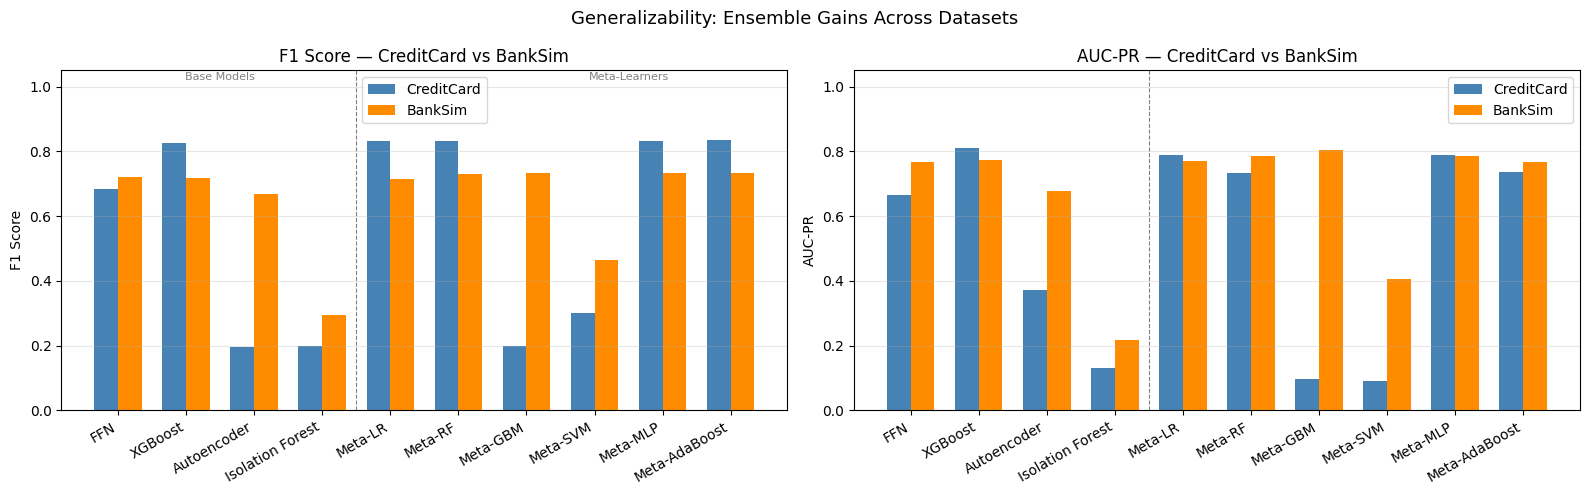

=== Cross-Dataset Comparison ===


,CC F1,CC AUC-PR,BS F1,BS AUC-PR,ΔF1 (BS-CC)
Model,,,,,
FFN,0.682900,0.663500,0.719500,0.765900,0.036500
XGBoost,0.824400,0.810600,0.718300,0.772100,-0.106100
Autoencoder,0.194200,0.370500,0.669300,0.677900,0.475100
Isolation Forest,0.198800,0.130100,0.295500,0.217900,0.096700
Meta-LR,0.830800,0.788700,0.715100,0.769800,-0.115700
Meta-RF,0.830800,0.734100,0.730300,0.785900,-0.100500
Meta-GBM,0.197800,0.097600,0.732300,0.803400,0.534500
Meta-SVM,0.301700,0.091300,0.465600,0.406700,0.163900
Meta-MLP,0.830800,0.788000,0.732200,0.784600,-0.098600


In [15]:
# Cross-dataset comparison: CreditCard vs BankSim side-by-side
cc_map = {r["name"]: r for r in all_results}
bs_map = {r["name"].replace("BS-", ""): r for r in bs_results}
shared_names = list(bs_map.keys())

cc_f1 = [cc_map[n]["F1"] for n in shared_names]
bs_f1 = [bs_map[n]["F1"] for n in shared_names]
cc_ap = [cc_map[n]["AUC-PR"] for n in shared_names]
bs_ap = [bs_map[n]["AUC-PR"] for n in shared_names]

x = np.arange(len(shared_names))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(x - w/2, cc_f1, w, label="CreditCard", color="steelblue")
axes[0].bar(x + w/2, bs_f1, w, label="BankSim", color="darkorange")
axes[0].set_xticks(x); axes[0].set_xticklabels(shared_names, rotation=30, ha="right")
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("F1 Score")
axes[0].set_title("F1 Score — CreditCard vs BankSim")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)
axes[0].axvline(x=3.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].text(1.5, 1.02, "Base Models", ha="center", fontsize=8, color="gray")
axes[0].text(7.5, 1.02, "Meta-Learners", ha="center", fontsize=8, color="gray")

axes[1].bar(x - w/2, cc_ap, w, label="CreditCard", color="steelblue")
axes[1].bar(x + w/2, bs_ap, w, label="BankSim", color="darkorange")
axes[1].set_xticks(x); axes[1].set_xticklabels(shared_names, rotation=30, ha="right")
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel("AUC-PR")
axes[1].set_title("AUC-PR — CreditCard vs BankSim")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)
axes[1].axvline(x=3.5, color="gray", linestyle="--", linewidth=0.8)

plt.suptitle("Generalizability: Ensemble Gains Across Datasets", fontsize=13)
plt.tight_layout(); plt.show()

# Summary table
rows = []
for n in shared_names:
    rows.append({
        "Model": n,
        "CC F1": round(cc_map[n]["F1"], 4),
        "CC AUC-PR": round(cc_map[n]["AUC-PR"], 4),
        "BS F1": round(bs_map[n]["F1"], 4),
        "BS AUC-PR": round(bs_map[n]["AUC-PR"], 4),
        "ΔF1 (BS-CC)": round(bs_map[n]["F1"] - cc_map[n]["F1"], 4),
    })

comp_df = pd.DataFrame(rows).set_index("Model")
styled_comp = comp_df.style.background_gradient(cmap="RdYlGn", subset=["CC F1", "BS F1", "CC AUC-PR", "BS AUC-PR"], vmin=0, vmax=1)
print("=== Cross-Dataset Comparison ===")
display(styled_comp)

## 7. Bootstrap Confidence Intervals

Resample the test set with replacement `N_BOOT` times, recompute the metric on each resample, and take the 2.5th / 97.5th percentiles as a 95% CI.

Results are misleading with only 71 fraud cases in CreditCard test. CIs tell us whether model differences are real or not.

In [16]:
N_BOOT = 1000

def bootstrap_ci(probs, labels, threshold=None, metric="f1", n_boot=N_BOOT, seed=SEED):
    """Returns (point_estimate, lower_95, upper_95)."""
    rng = np.random.default_rng(seed)
    n = len(labels)
    if metric == "f1":
        point = f1_score(labels, (probs >= threshold).astype(int), zero_division=0)
    else:
        point = average_precision_score(labels, probs)
    boot_vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        l_b = labels[idx]
        if l_b.sum() == 0 or l_b.sum() == n:
            continue
        p_b = probs[idx]
        if metric == "f1":
            v = f1_score(l_b, (p_b >= threshold).astype(int), zero_division=0)
        else:
            v = average_precision_score(l_b, p_b)
        boot_vals.append(v)
    boot_vals = np.array(boot_vals)
    return point, float(np.percentile(boot_vals, 2.5)), float(np.percentile(boot_vals, 97.5))


def compute_all_ci(results, y_true, dataset_name, n_boot=N_BOOT):
    rows = []
    for r in results:
        f1_pt, f1_lo, f1_hi = bootstrap_ci(r["test_probs"], y_true, threshold=r["thresh"],
                                           metric="f1", n_boot=n_boot)
        ap_pt, ap_lo, ap_hi = bootstrap_ci(r["test_probs"], y_true,
                                           metric="auc_pr", n_boot=n_boot)
        rows.append({
            "dataset": dataset_name,
            "model": r["name"].replace("BS-", ""),
            "f1": round(f1_pt, 4),
            "f1_lo": round(f1_lo, 4),
            "f1_hi": round(f1_hi, 4),
            "auc_pr": round(ap_pt, 4),
            "auc_pr_lo": round(ap_lo, 4),
            "auc_pr_hi": round(ap_hi, 4),
        })
    return pd.DataFrame(rows)


print(f"Computing bootstrap CIs")
print("  CreditCard")
cc_ci_df = compute_all_ci(all_results, y_test, "CreditCard")
print("  BankSim")
bs_ci_df = compute_all_ci(bs_results, y_bs_test, "BankSim")

ci_df = pd.concat([cc_ci_df, bs_ci_df], ignore_index=True)
ci_df.to_csv(f"{RESULTS_DIR}/all_results_with_ci.csv", index=False)
print(f"\nSaved all_results_with_ci.csv\n")

# Print formatted table
print(f"{'Dataset':<12} {'Model':<20} {'F1 [95% CI]':<28} {'AUC-PR [95% CI]':<28}")
print("-" * 90)
for _, row in ci_df.iterrows():
    print(f"{row['dataset']:<12} {row['model']:<20} "
          f"{row['f1']:.3f} [{row['f1_lo']:.3f}, {row['f1_hi']:.3f}]      "
          f"{row['auc_pr']:.3f} [{row['auc_pr_lo']:.3f}, {row['auc_pr_hi']:.3f}]")

Computing bootstrap CIs
  CreditCard
  BankSim

Saved all_results_with_ci.csv

Dataset      Model                F1 [95% CI]                  AUC-PR [95% CI]             
------------------------------------------------------------------------------------------
CreditCard   FFN                  0.683 [0.597, 0.763]      0.663 [0.539, 0.772]
CreditCard   XGBoost              0.824 [0.746, 0.895]      0.811 [0.719, 0.894]
CreditCard   Autoencoder          0.194 [0.153, 0.240]      0.370 [0.264, 0.490]
CreditCard   Isolation Forest     0.199 [0.141, 0.253]      0.130 [0.086, 0.203]
CreditCard   Meta-LR              0.831 [0.755, 0.899]      0.789 [0.696, 0.878]
CreditCard   Meta-RF              0.831 [0.755, 0.899]      0.734 [0.606, 0.856]
CreditCard   Meta-GBM             0.198 [0.091, 0.298]      0.098 [0.033, 0.178]
CreditCard   Meta-SVM             0.302 [0.242, 0.365]      0.091 [0.068, 0.123]
CreditCard   Meta-MLP             0.831 [0.755, 0.899]      0.788 [0.693, 0.878]
CreditCar

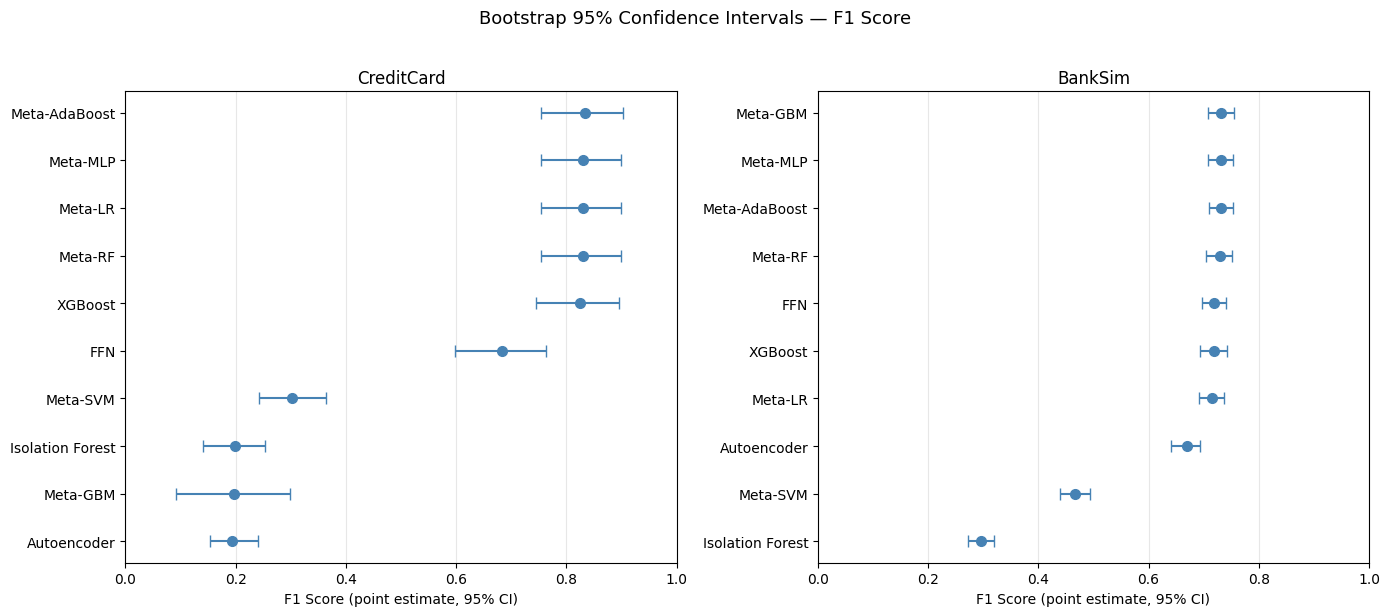


=== Pairs with NON-overlapping F1 CIs (statistically distinguishable) ===

CreditCard:
  FFN (0.683) > Autoencoder (0.194)
  FFN (0.683) > Isolation Forest (0.199)
  FFN (0.683) > Meta-GBM (0.198)
  FFN (0.683) > Meta-SVM (0.302)
  XGBoost (0.824) > Autoencoder (0.194)
  XGBoost (0.824) > Isolation Forest (0.199)
  XGBoost (0.824) > Meta-GBM (0.198)
  XGBoost (0.824) > Meta-SVM (0.302)
  Meta-LR (0.831) > Autoencoder (0.194)
  Meta-RF (0.831) > Autoencoder (0.194)
  Meta-SVM (0.302) > Autoencoder (0.194)
  Meta-MLP (0.831) > Autoencoder (0.194)
  Meta-AdaBoost (0.835) > Autoencoder (0.194)
  Meta-LR (0.831) > Isolation Forest (0.199)
  Meta-RF (0.831) > Isolation Forest (0.199)
  Meta-MLP (0.831) > Isolation Forest (0.199)
  Meta-AdaBoost (0.835) > Isolation Forest (0.199)
  Meta-LR (0.831) > Meta-GBM (0.198)
  Meta-LR (0.831) > Meta-SVM (0.302)
  Meta-RF (0.831) > Meta-GBM (0.198)
  Meta-RF (0.831) > Meta-SVM (0.302)
  Meta-MLP (0.831) > Meta-GBM (0.198)
  Meta-AdaBoost (0.835) > Met

In [17]:
# Forest plot F1 score with 95% bootstrap CIs
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, ds in zip(axes, ["CreditCard", "BankSim"]):
    df = ci_df[ci_df["dataset"] == ds].sort_values("f1").reset_index(drop=True)
    y_pos = np.arange(len(df))
    err_lo = (df["f1"] - df["f1_lo"]).clip(lower=0)
    err_hi = (df["f1_hi"] - df["f1"]).clip(lower=0)
    ax.errorbar(df["f1"], y_pos, xerr=[err_lo, err_hi],
                fmt="o", color="steelblue", capsize=4, markersize=7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df["model"])
    ax.set_xlabel("F1 Score (point estimate, 95% CI)")
    ax.set_title(ds)
    ax.grid(axis="x", alpha=0.3)
    ax.set_xlim(0, 1)

plt.suptitle("Bootstrap 95% Confidence Intervals — F1 Score", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


# Overlap check
print("\n=== Pairs with NON-overlapping F1 CIs (statistically distinguishable) ===")
for ds in ["CreditCard", "BankSim"]:
    df = ci_df[ci_df["dataset"] == ds].reset_index(drop=True)
    print(f"\n{ds}:")
    pairs_found = 0
    for i in range(len(df)):
        for j in range(i + 1, len(df)):
            a, b = df.iloc[i], df.iloc[j]
            # Non-overlap
            if a["f1_lo"] > b["f1_hi"] or b["f1_lo"] > a["f1_hi"]:
                hi, lo = (a, b) if a["f1"] > b["f1"] else (b, a)
                print(f"  {hi['model']} ({hi['f1']:.3f}) > {lo['model']} ({lo['f1']:.3f})")
                pairs_found += 1
    if pairs_found == 0:
        print("  (none — all model differences are within noise)")